# Qwen2-VL-2B × MMAD — Deep Analysis

Notebook này phân tích toàn bộ **39,670 câu hỏi MMAD** ở mức tổng thể, task, source dataset, category và anomaly detection. Mục tiêu là tìm điểm mạnh, điểm chết và shortcut/bias của mô hình, không chỉ báo một con số accuracy.

**Giới hạn:** benchmark chỉ lưu đáp án A/B/C/D, không lưu logits hoặc xác suất. Vì vậy ECE, Brier score và selective-risk theo confidence **không thể tính hợp lệ**. Accuracy theo task cũng không tự động đồng nghĩa với causal reasoning.

In [1]:
from pathlib import Path
import json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from IPython.display import display, Markdown
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120

cwd = Path.cwd()
direct = cwd / 'predictions_scored.csv'
if direct.exists():
    DATA_DIR = cwd
else:
    candidates = list(cwd.rglob('qwen2_vl_mmad_full_results/predictions_scored.csv'))
    assert candidates, 'Không tìm thấy folder qwen2_vl_mmad_full_results'
    DATA_DIR = candidates[0].parent
OUT = DATA_DIR / 'deep_analysis'
OUT.mkdir(exist_ok=True)
df = pd.read_csv(DATA_DIR / 'predictions_scored.csv')
metrics = json.loads((DATA_DIR / 'metrics.json').read_text(encoding='utf-8'))
print('DATA_DIR:', DATA_DIR)
print('shape:', df.shape)
display(df.head(3))

DATA_DIR: C:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision\research\mmad_model_benchmark\models\qwen2_vl\qwen2_vl_mmad_full_results
shape: (39670, 12)


,sample_id,model,source_dataset,category,question_type,is_normal,truth,prediction,parse_valid,correct,status,latency_seconds
0,mmad_full_00001,Qwen/Qwen2-VL-2B-Instruct,MVTec-AD,bottle,Anomaly Detection,False,A,A,True,True,ok,0.8443
1,mmad_full_00002,Qwen/Qwen2-VL-2B-Instruct,MVTec-AD,bottle,Anomaly Detection,False,A,A,True,True,ok,0.8443
2,mmad_full_00003,Qwen/Qwen2-VL-2B-Instruct,MVTec-AD,bottle,Anomaly Detection,False,B,B,True,True,ok,0.8443


## 1. Data integrity và benchmark coverage

In [2]:
audit = {
    'expected_records': metrics['expected_records'],
    'rows_in_scored_csv': len(df),
    'unique_sample_ids': df.sample_id.nunique(),
    'duplicate_ids': int(df.sample_id.duplicated().sum()),
    'parsed_records': int(df.parse_valid.sum()),
    'parse_failures': int((~df.parse_valid).sum()),
    'missing_predictions': int(df.prediction.isna().sum()),
    'sources': df.source_dataset.nunique(),
    'categories': df.category.nunique(),
    'tasks': df.question_type.nunique(),
}
display(pd.Series(audit, name='value').to_frame())
assert len(df) == metrics['expected_records'] == 39670
assert df.sample_id.nunique() == len(df)
valid = df[df.parse_valid].copy()
print('Integrity: PASS')

,value
expected_records,39670
rows_in_scored_csv,39670
unique_sample_ids,39670
duplicate_ids,0
parsed_records,39669
parse_failures,1
missing_predictions,1
sources,4
categories,38
tasks,7


Integrity: PASS


## 2. Executive metrics và khoảng tin cậy 95%

In [3]:
def wilson(k, n, alpha=0.05):
    if n == 0: return (np.nan, np.nan)
    z = norm.ppf(1-alpha/2); p = k/n
    den = 1 + z*z/n
    center = (p + z*z/(2*n))/den
    half = z*math.sqrt(p*(1-p)/n + z*z/(4*n*n))/den
    return center-half, center+half

k, n = int(valid.correct.sum()), len(valid)
lo, hi = wilson(k, n)
ad = metrics['anomaly_detection']
overview = pd.DataFrame([
    ['Completion rate', metrics['completion_rate'], np.nan, np.nan],
    ['Parse-valid rate', 1-metrics['parse_failure_rate'], np.nan, np.nan],
    ['Micro accuracy', metrics['micro_accuracy'], lo, hi],
    ['Macro task accuracy', metrics['macro_task_accuracy'], np.nan, np.nan],
    ['Anomaly precision', ad['precision'], np.nan, np.nan],
    ['Anomaly recall', ad['recall'], np.nan, np.nan],
    ['Anomaly F1', ad['f1'], np.nan, np.nan],
    ['Anomaly miss rate', ad['miss_rate'], np.nan, np.nan],
], columns=['metric','value','ci_low','ci_high'])
display(overview.style.format({'value':'{:.2%}','ci_low':'{:.2%}','ci_high':'{:.2%}'}))
overview.to_csv(OUT/'executive_metrics.csv', index=False)

,metric,value,ci_low,ci_high
0,Completion rate,100.00%,nan%,nan%
1,Parse-valid rate,100.00%,nan%,nan%
2,Micro accuracy,64.73%,64.26%,65.20%
3,Macro task accuracy,65.03%,nan%,nan%
4,Anomaly precision,74.28%,nan%,nan%
5,Anomaly recall,48.07%,nan%,nan%
6,Anomaly F1,58.37%,nan%,nan%
7,Anomaly miss rate,51.93%,nan%,nan%


## 3. Distribution của dữ liệu đánh giá

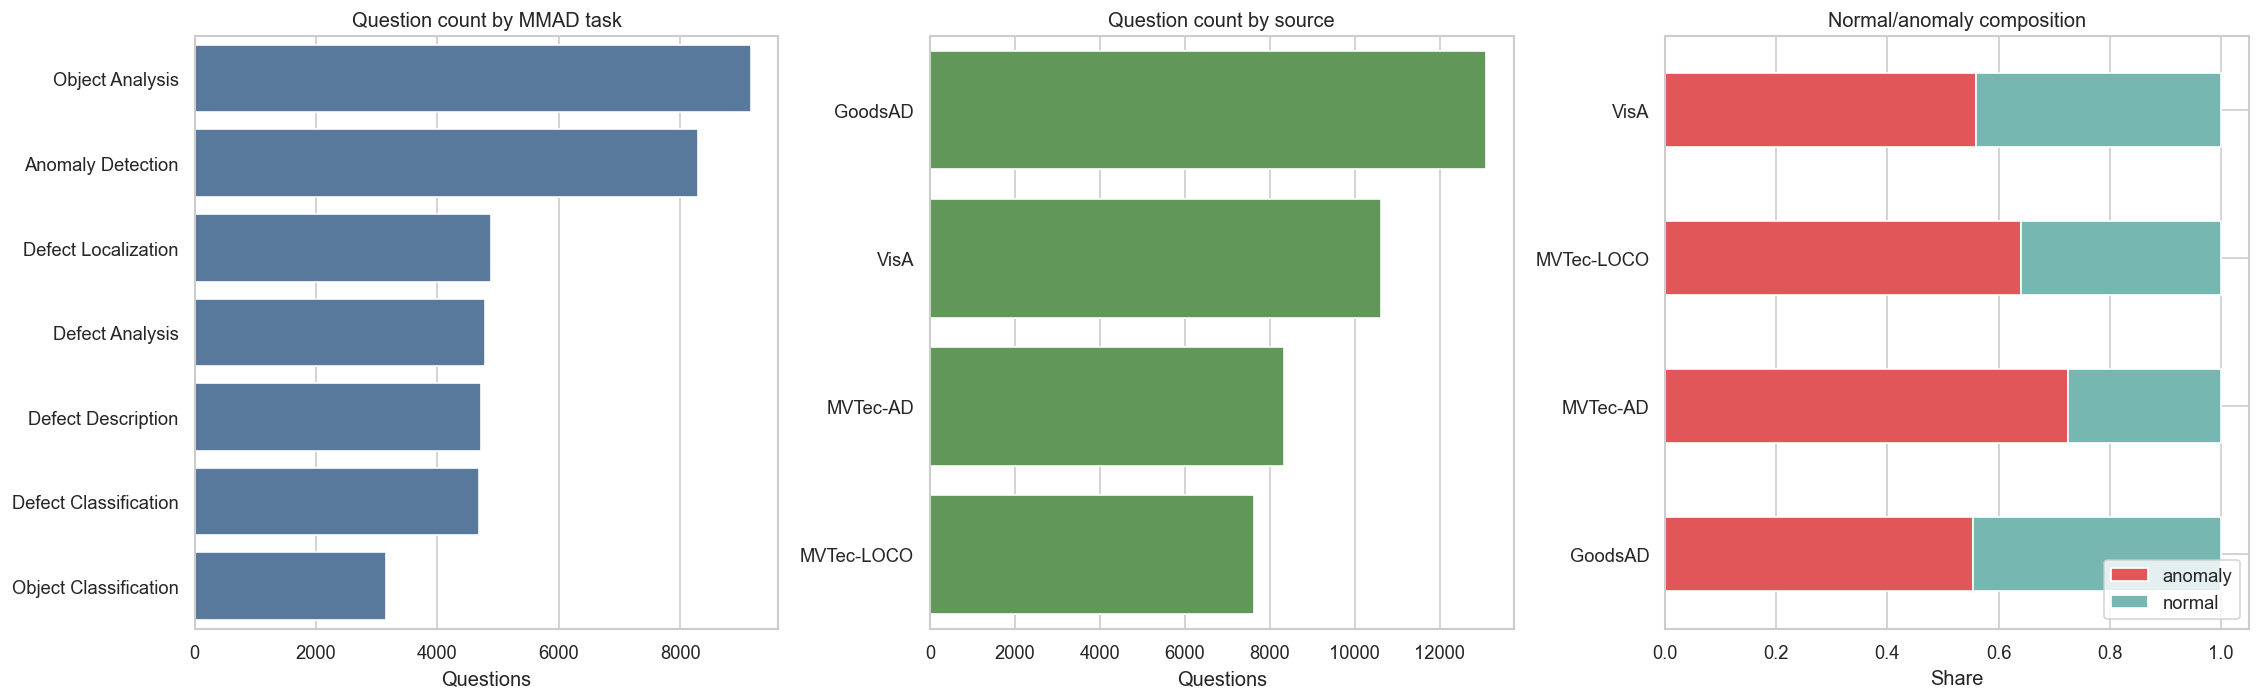

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(19, 6))
sns.countplot(data=df, y='question_type', order=df.question_type.value_counts().index, ax=ax[0], color='#4C78A8')
ax[0].set_title('Question count by MMAD task'); ax[0].set_xlabel('Questions'); ax[0].set_ylabel('')
sns.countplot(data=df, y='source_dataset', order=df.source_dataset.value_counts().index, ax=ax[1], color='#59A14F')
ax[1].set_title('Question count by source'); ax[1].set_xlabel('Questions'); ax[1].set_ylabel('')
normal_mix = pd.crosstab(df.source_dataset, df.is_normal, normalize='index').rename(columns={False:'anomaly', True:'normal'})
normal_mix.plot(kind='barh', stacked=True, ax=ax[2], color=['#E15759','#76B7B2'])
ax[2].set_title('Normal/anomaly composition'); ax[2].set_xlabel('Share'); ax[2].set_ylabel(''); ax[2].legend(loc='lower right')
plt.tight_layout(); plt.savefig(OUT/'01_data_distribution.png', bbox_inches='tight'); plt.show()

## 4. Accuracy theo task và source (Wilson 95% CI)

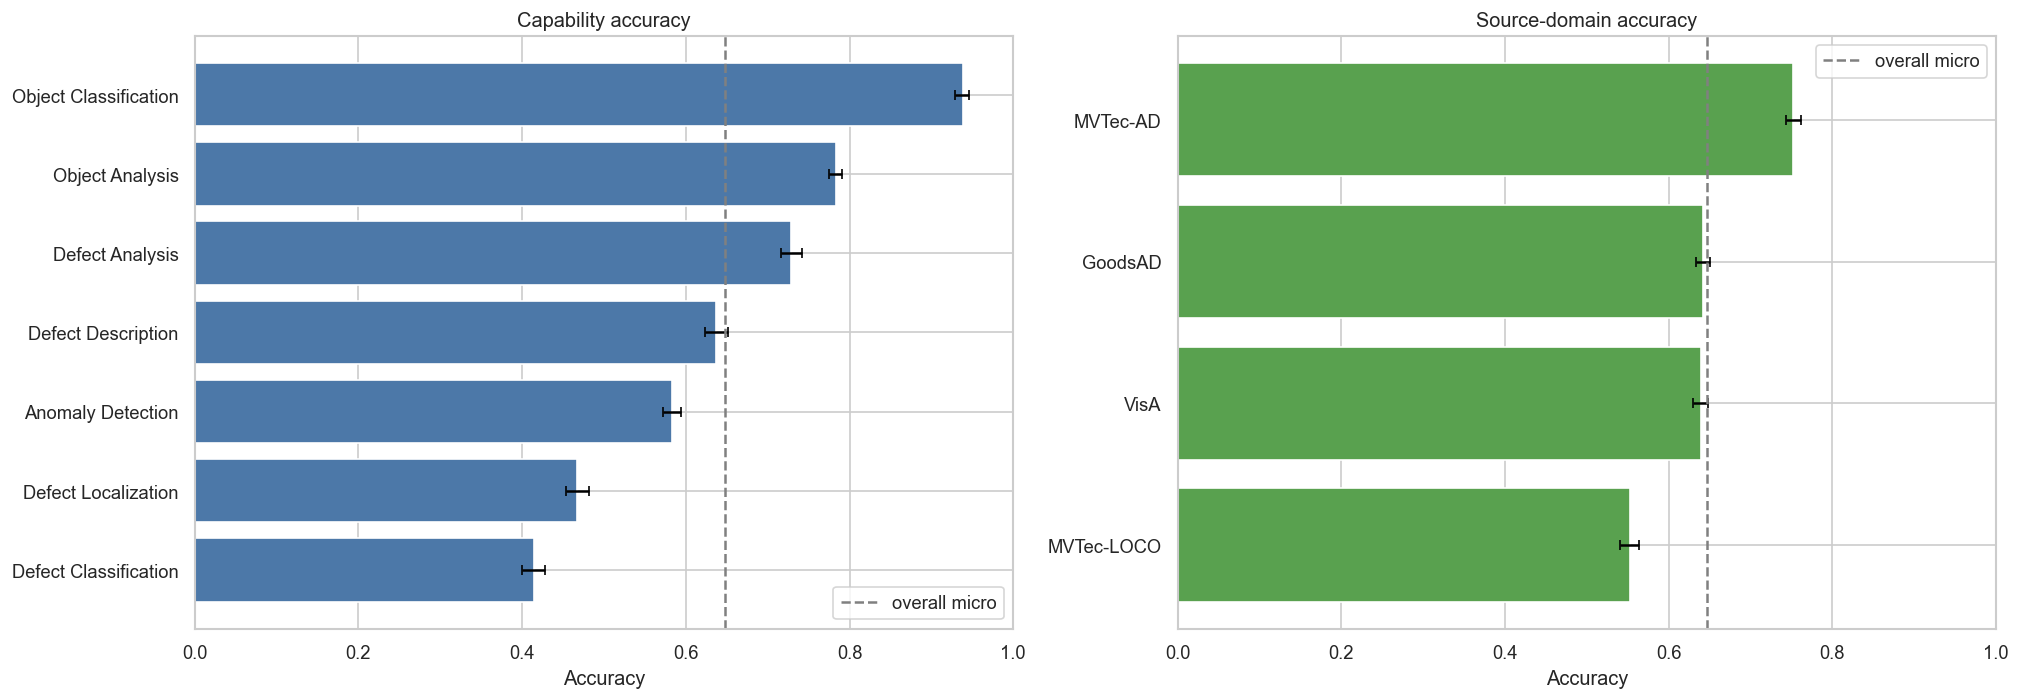

,question_type,n,correct_n,accuracy,ci_low,ci_high
2,Defect Classification,4688,1942,0.414249,0.400224,0.428414
4,Defect Localization,4877,2279,0.467295,0.453324,0.481318
0,Anomaly Detection,8297,4838,0.583102,0.572457,0.593670
3,Defect Description,4710,3002,0.637367,0.623531,0.650980
1,Defect Analysis,4782,3486,0.728984,0.716206,0.741394
5,Object Analysis,9160,7172,0.782969,0.774410,0.791292
6,Object Classification,3155,2960,0.938193,0.929246,0.946075


,source_dataset,n,correct_n,accuracy,ci_low,ci_high
2,MVTec-LOCO,7624,4210,0.552204,0.541018,0.563337
3,VisA,10621,6790,0.639300,0.630118,0.648380
0,GoodsAD,13088,8406,0.642268,0.634015,0.650437
1,MVTec-AD,8336,6273,0.752519,0.743140,0.761665


In [5]:
def grouped_accuracy(data, keys):
    out = data.groupby(keys, observed=True).correct.agg(['count','sum','mean']).reset_index()
    cis = out.apply(lambda r: wilson(int(r['sum']), int(r['count'])), axis=1)
    out['ci_low'] = [x[0] for x in cis]; out['ci_high'] = [x[1] for x in cis]
    return out.rename(columns={'count':'n','sum':'correct_n','mean':'accuracy'})

task_perf = grouped_accuracy(valid, ['question_type']).sort_values('accuracy')
source_perf = grouped_accuracy(valid, ['source_dataset']).sort_values('accuracy')
fig, ax = plt.subplots(1, 2, figsize=(17, 6))
for axis, table, label, color in [(ax[0],task_perf,'question_type','#4C78A8'),(ax[1],source_perf,'source_dataset','#59A14F')]:
    axis.barh(table[label], table.accuracy, color=color)
    axis.errorbar(table.accuracy, table[label], xerr=[table.accuracy-table.ci_low, table.ci_high-table.accuracy], fmt='none', color='black', capsize=3)
    axis.axvline(metrics['micro_accuracy'], ls='--', color='gray', label='overall micro')
    axis.set_xlim(0,1); axis.set_xlabel('Accuracy'); axis.legend()
ax[0].set_title('Capability accuracy'); ax[1].set_title('Source-domain accuracy')
plt.tight_layout(); plt.savefig(OUT/'02_task_source_accuracy_ci.png', bbox_inches='tight'); plt.show()
display(task_perf); display(source_perf)
task_perf.to_csv(OUT/'task_performance_ci.csv',index=False); source_perf.to_csv(OUT/'source_performance_ci.csv',index=False)

## 5. Interaction giữa task và source dataset

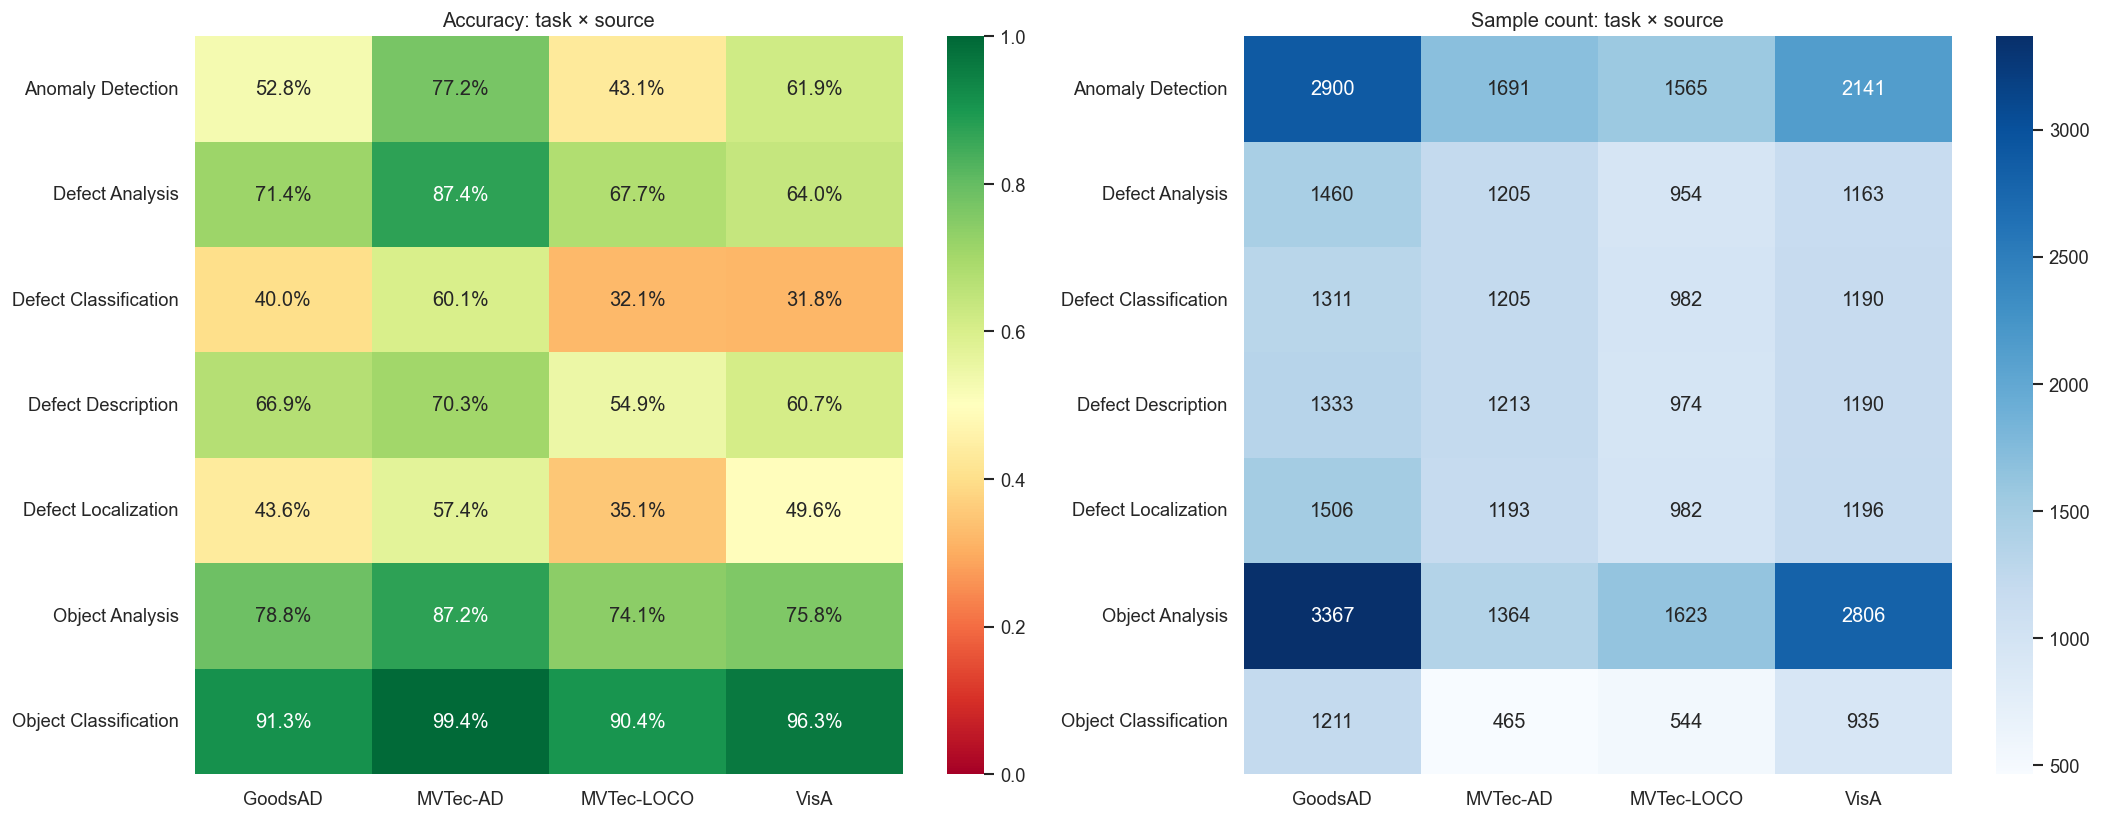

In [6]:
task_source = grouped_accuracy(valid, ['question_type','source_dataset'])
acc_hm = task_source.pivot(index='question_type',columns='source_dataset',values='accuracy')
n_hm = task_source.pivot(index='question_type',columns='source_dataset',values='n')
fig, ax = plt.subplots(1,2,figsize=(18,7))
sns.heatmap(acc_hm, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=1, ax=ax[0])
ax[0].set_title('Accuracy: task × source'); ax[0].set_xlabel(''); ax[0].set_ylabel('')
sns.heatmap(n_hm, annot=True, fmt='.0f', cmap='Blues', ax=ax[1])
ax[1].set_title('Sample count: task × source'); ax[1].set_xlabel(''); ax[1].set_ylabel('')
plt.tight_layout(); plt.savefig(OUT/'03_task_source_heatmaps.png',bbox_inches='tight'); plt.show()
task_source.to_csv(OUT/'task_source_slices.csv',index=False)

## 6. Answer-position bias và confusion A/B/C/D

Phân tích này phát hiện mô hình có ưu tiên một vị trí đáp án hay không. Đây là bias của giao diện MCQ, không phải trực tiếp là năng lực nhận diện lỗi.

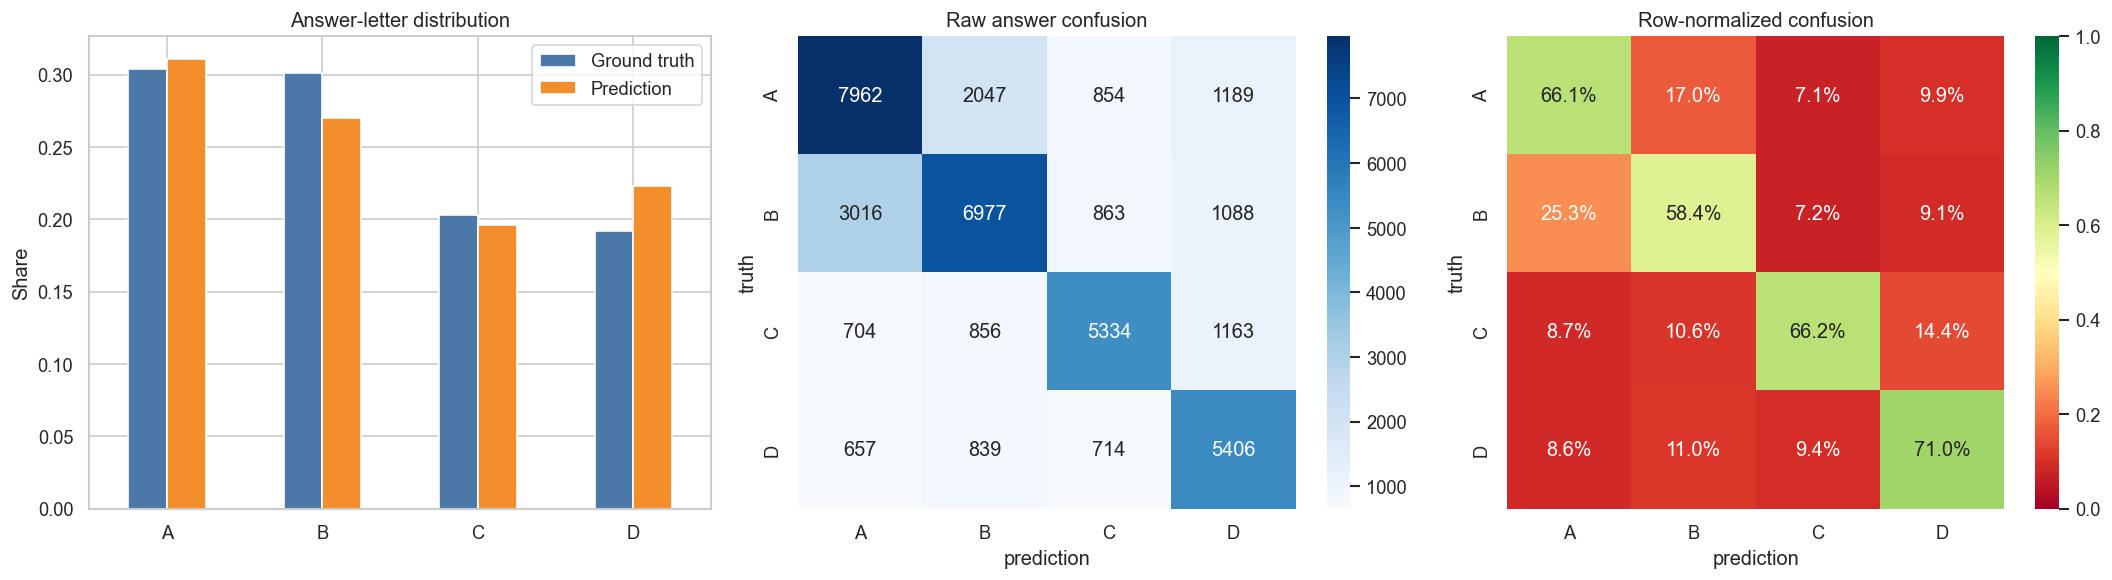

,truth_share,prediction_share,delta
A,30.38%,31.10%,0.72%
B,30.11%,27.02%,-3.09%
C,20.31%,19.57%,-0.74%
D,19.20%,22.30%,3.10%


In [7]:
letters = ['A','B','C','D']
truth_dist = valid.truth.value_counts(normalize=True).reindex(letters,fill_value=0)
pred_dist = valid.prediction.value_counts(normalize=True).reindex(letters,fill_value=0)
cm = pd.crosstab(valid.truth, valid.prediction).reindex(index=letters,columns=letters,fill_value=0)
cm_row = cm.div(cm.sum(axis=1),axis=0)
fig, ax = plt.subplots(1,3,figsize=(18,5))
pd.DataFrame({'Ground truth':truth_dist,'Prediction':pred_dist}).plot(kind='bar',ax=ax[0],color=['#4C78A8','#F28E2B'])
ax[0].set_title('Answer-letter distribution'); ax[0].set_ylabel('Share'); ax[0].tick_params(axis='x',rotation=0)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax[1]); ax[1].set_title('Raw answer confusion')
sns.heatmap(cm_row,annot=True,fmt='.1%',cmap='RdYlGn',vmin=0,vmax=1,ax=ax[2]); ax[2].set_title('Row-normalized confusion')
plt.tight_layout(); plt.savefig(OUT/'04_answer_bias_confusion.png',bbox_inches='tight'); plt.show()
answer_bias = pd.DataFrame({'truth_share':truth_dist,'prediction_share':pred_dist,'delta':pred_dist-truth_dist})
display(answer_bias.style.format('{:.2%}')); answer_bias.to_csv(OUT/'answer_position_bias.csv')

## 7. Anomaly detection: miss và overkill theo source

,source_dataset,n,precision,recall,f1,miss_rate,overkill_rate,tp,fp,tn,fn
0,GoodsAD,2900.000000,73.27%,25.38%,37.70%,74.62%,11.90%,414.000000,151.000000,1118.000000,1217.000000
1,MVTec-AD,1691.000000,84.95%,83.36%,84.15%,16.64%,38.92%,1022.000000,181.000000,284.000000,204.000000
2,MVTec-LOCO,1565.000000,72.17%,16.73%,27.17%,83.27%,11.17%,166.000000,64.000000,509.000000,826.000000
3,VisA,2141.000000,65.04%,68.95%,66.94%,31.05%,47.08%,826.000000,444.000000,499.000000,372.000000


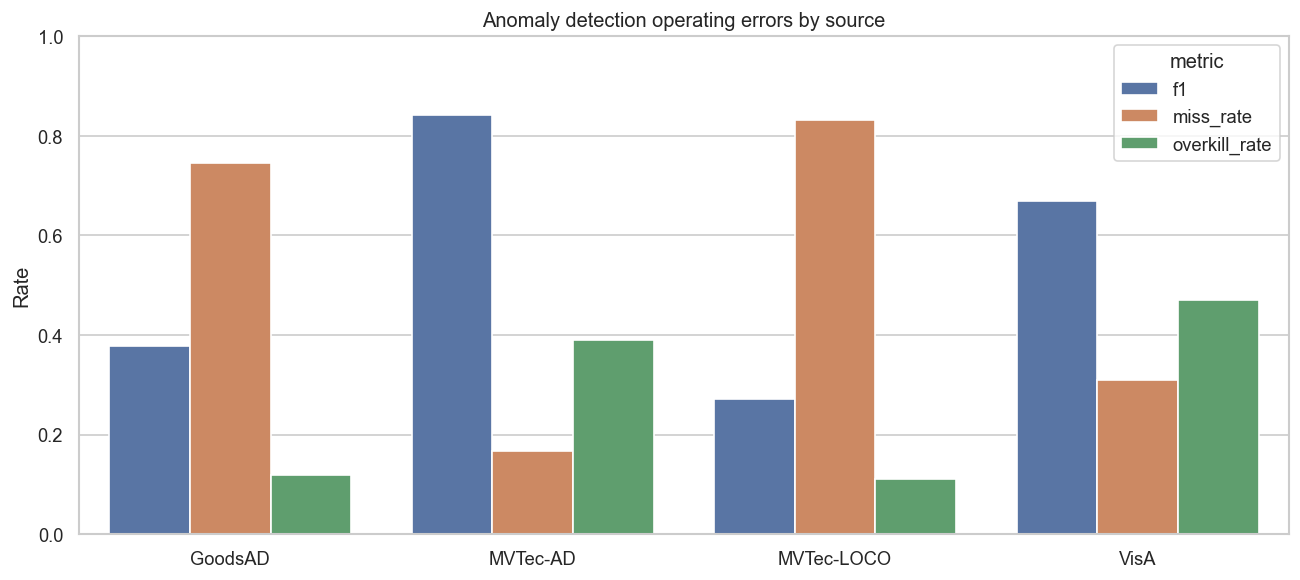

In [8]:
det = valid[valid.question_type.eq('Anomaly Detection')].copy()
det['actual_anomaly'] = ~det.is_normal
# Anomaly Detection là binary; với parse-valid row, đáp án sai chính là lớp đối diện.
det['predicted_anomaly'] = np.where(det.correct, det.actual_anomaly, ~det.actual_anomaly)
def detection_metrics(g):
    a=g.actual_anomaly.to_numpy(); p=g.predicted_anomaly.to_numpy()
    tp=int((a&p).sum()); fp=int((~a&p).sum()); tn=int((~a&~p).sum()); fn=int((a&~p).sum())
    precision=tp/(tp+fp) if tp+fp else np.nan; recall=tp/(tp+fn) if tp+fn else np.nan
    f1=2*precision*recall/(precision+recall) if precision+recall else np.nan
    return pd.Series({'n':len(g),'precision':precision,'recall':recall,'f1':f1,'miss_rate':fn/(tp+fn),'overkill_rate':fp/(tn+fp),'tp':tp,'fp':fp,'tn':tn,'fn':fn})
det_source = det.groupby('source_dataset', group_keys=False).apply(detection_metrics).reset_index()
display(det_source.style.format({c:'{:.2%}' for c in ['precision','recall','f1','miss_rate','overkill_rate']}))
plot_det = det_source.melt(id_vars='source_dataset',value_vars=['f1','miss_rate','overkill_rate'],var_name='metric',value_name='value')
plt.figure(figsize=(11,5)); sns.barplot(data=plot_det,x='source_dataset',y='value',hue='metric')
plt.ylim(0,1); plt.ylabel('Rate'); plt.xlabel(''); plt.title('Anomaly detection operating errors by source')
plt.tight_layout(); plt.savefig(OUT/'05_anomaly_by_source.png',bbox_inches='tight'); plt.show()
det_source.to_csv(OUT/'anomaly_by_source.csv',index=False)

## 8. Hardest categories và worst-case slices

### 20 category khó nhất (n ≥ 30)

,source_dataset,category,n,correct_n,accuracy,ci_low,ci_high
32,VisA,macaroni2,1000,501,0.501000,0.470066,0.531927
24,MVTec-LOCO,screw_bag,1703,889,0.522020,0.498273,0.545668
21,MVTec-LOCO,breakfast_box,1284,671,0.522586,0.495238,0.549798
22,MVTec-LOCO,juice_bottle,1637,879,0.536958,0.512745,0.560998
2,GoodsAD,drink_can,1297,760,0.585968,0.558946,0.612481
25,MVTec-LOCO,splicing_connectors,1513,890,0.588235,0.563244,0.612780
23,MVTec-LOCO,pushpins,1487,881,0.592468,0.567286,0.617174
30,VisA,fryum,750,454,0.605333,0.569901,0.639692
37,VisA,pipe_fryum,643,392,0.609642,0.571392,0.646591
28,VisA,cashew,744,458,0.615591,0.580128,0.649867


### 25 source × category × task khó nhất (n ≥ 20)

,source_dataset,category,question_type,n,correct_n,accuracy,ci_low,ci_high
219,VisA,macaroni1,Defect Classification,100,7,0.070000,0.034319,0.137495
226,VisA,macaroni2,Defect Classification,100,11,0.110000,0.062542,0.186313
198,VisA,cashew,Defect Classification,100,20,0.200000,0.133367,0.288829
228,VisA,macaroni2,Defect Localization,100,25,0.250000,0.175452,0.343045
16,GoodsAD,drink_can,Defect Classification,134,36,0.268657,0.200826,0.349382
37,GoodsAD,food_package,Defect Classification,209,57,0.272727,0.216857,0.336802
177,MVTec-LOCO,splicing_connectors,Defect Classification,193,54,0.279793,0.221233,0.346947
205,VisA,chewinggum,Defect Classification,99,28,0.282828,0.203520,0.378361
149,MVTec-LOCO,breakfast_box,Defect Classification,172,50,0.290698,0.227999,0.362541
11,GoodsAD,drink_bottle,Defect Localization,394,122,0.309645,0.266014,0.356952


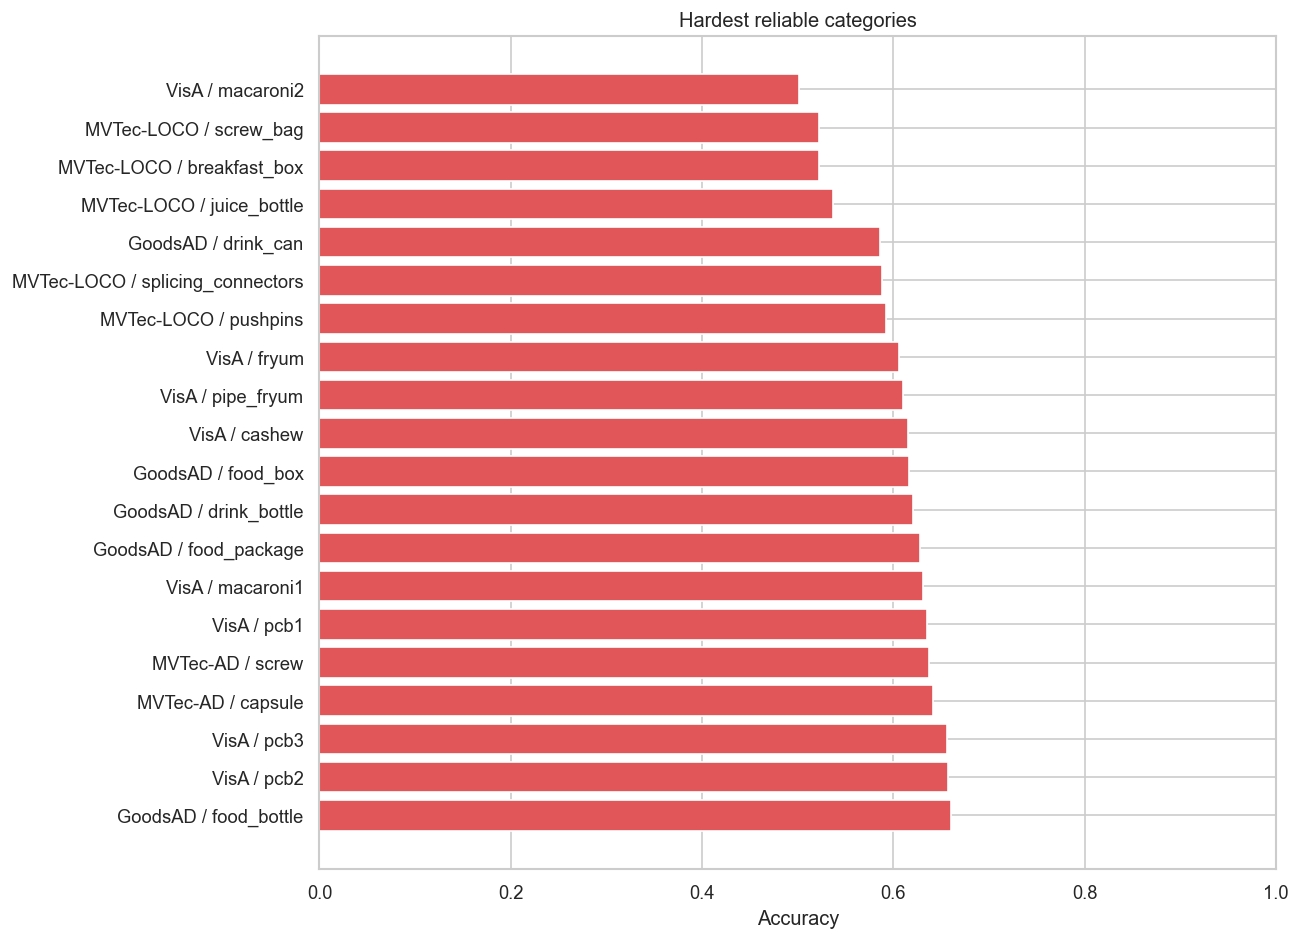

In [9]:
category_perf = grouped_accuracy(valid,['source_dataset','category'])
category_reliable = category_perf[category_perf.n >= 30].sort_values('accuracy')
slice_perf = grouped_accuracy(valid,['source_dataset','category','question_type'])
slice_reliable = slice_perf[slice_perf.n >= 20].sort_values('accuracy')
display(Markdown('### 20 category khó nhất (n ≥ 30)'))
display(category_reliable.head(20))
display(Markdown('### 25 source × category × task khó nhất (n ≥ 20)'))
display(slice_reliable.head(25))
hard = category_reliable.head(20).copy(); hard['name']=hard.source_dataset+' / '+hard.category
plt.figure(figsize=(11,8)); plt.barh(hard.name[::-1],hard.accuracy[::-1],color='#E15759')
plt.xlim(0,1); plt.xlabel('Accuracy'); plt.title('Hardest reliable categories')
plt.tight_layout(); plt.savefig(OUT/'06_hardest_categories.png',bbox_inches='tight'); plt.show()
category_perf.to_csv(OUT/'category_performance.csv',index=False)
slice_perf.to_csv(OUT/'fine_grained_slices.csv',index=False)

## 9. Error concentration (Pareto) và latency

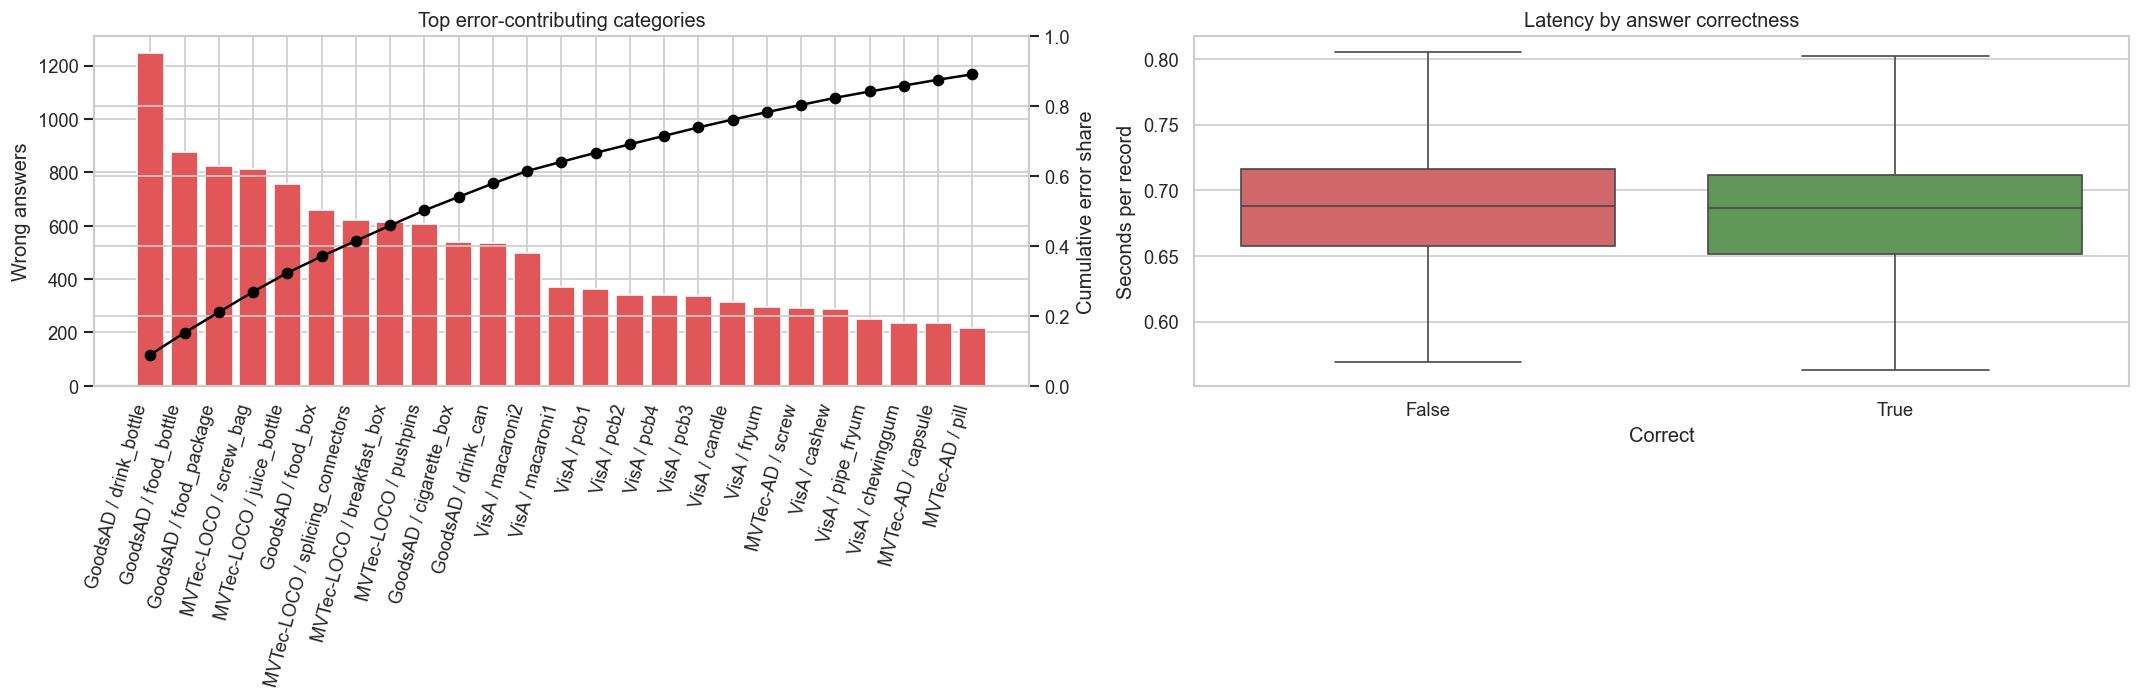

,question_type,correct,n,mean,median,p95
0,Anomaly Detection,False,3459,0.746735,0.75580,0.797620
1,Anomaly Detection,True,4838,0.748247,0.75775,0.798700
2,Defect Analysis,False,1296,0.679468,0.68570,0.718750
3,Defect Analysis,True,3486,0.679006,0.68770,0.716200
4,Defect Classification,False,2746,0.678168,0.68205,0.722000
5,Defect Classification,True,1942,0.676421,0.68205,0.717595
6,Defect Description,False,1708,0.678604,0.68340,0.717530
7,Defect Description,True,3002,0.677595,0.68410,0.719300
8,Defect Localization,False,2598,0.675416,0.68260,0.718000
9,Defect Localization,True,2279,0.677347,0.68340,0.717000


Caution: latency được ghi theo batch nên các record không hoàn toàn độc lập; dùng để mô tả vận hành, không suy ra nhân quả.


In [10]:
errors = valid[~valid.correct].copy()
err_cat = errors.groupby(['source_dataset','category']).size().sort_values(ascending=False).reset_index(name='errors')
err_cat['share'] = err_cat.errors/err_cat.errors.sum(); err_cat['cumulative_share']=err_cat.share.cumsum()
top = err_cat.head(25).copy(); top['name']=top.source_dataset+' / '+top.category
fig, ax = plt.subplots(1,2,figsize=(18,6))
ax[0].bar(range(len(top)),top.errors,color='#E15759'); ax[0].set_xticks(range(len(top)),top.name,rotation=75,ha='right'); ax[0].set_title('Top error-contributing categories'); ax[0].set_ylabel('Wrong answers')
ax2=ax[0].twinx(); ax2.plot(range(len(top)),top.cumulative_share,color='black',marker='o'); ax2.set_ylim(0,1); ax2.set_ylabel('Cumulative error share')
sns.boxplot(data=valid,x='correct',y='latency_seconds',ax=ax[1],showfliers=False,palette=['#E15759','#59A14F'])
ax[1].set_title('Latency by answer correctness'); ax[1].set_xlabel('Correct'); ax[1].set_ylabel('Seconds per record')
plt.tight_layout(); plt.savefig(OUT/'07_error_pareto_latency.png',bbox_inches='tight'); plt.show()
lat = valid.groupby(['question_type','correct']).latency_seconds.agg(['count','mean','median',lambda x:x.quantile(.95)]).reset_index()
lat.columns=['question_type','correct','n','mean','median','p95']
display(lat); err_cat.to_csv(OUT/'error_pareto.csv',index=False); lat.to_csv(OUT/'latency_slices.csv',index=False)
print('Caution: latency được ghi theo batch nên các record không hoàn toàn độc lập; dùng để mô tả vận hành, không suy ra nhân quả.')

## 10. Kết luận tự động và research decision

In [11]:
best_task=task_perf.loc[task_perf.accuracy.idxmax()]; worst_task=task_perf.loc[task_perf.accuracy.idxmin()]
best_source=source_perf.loc[source_perf.accuracy.idxmax()]; worst_source=source_perf.loc[source_perf.accuracy.idxmin()]
max_bias=answer_bias.delta.abs().idxmax(); max_bias_value=answer_bias.loc[max_bias,'delta']
summary = f'''# Qwen2-VL-2B × MMAD: deep-analysis summary

- Coverage: {metrics['parsed_records']:,}/{metrics['expected_records']:,} parse-valid answers ({1-metrics['parse_failure_rate']:.3%}).
- Overall micro accuracy: {metrics['micro_accuracy']:.2%} (Wilson 95% CI {lo:.2%}–{hi:.2%}).
- Macro task accuracy: {metrics['macro_task_accuracy']:.2%}.
- Strongest task: {best_task.question_type} ({best_task.accuracy:.2%}, n={int(best_task.n):,}).
- Weakest task: {worst_task.question_type} ({worst_task.accuracy:.2%}, n={int(worst_task.n):,}).
- Strongest source: {best_source.source_dataset} ({best_source.accuracy:.2%}).
- Weakest source: {worst_source.source_dataset} ({worst_source.accuracy:.2%}).
- Anomaly detection: precision {ad['precision']:.2%}, recall {ad['recall']:.2%}, F1 {ad['f1']:.2%}; miss rate {ad['miss_rate']:.2%}, overkill {ad['overkill_rate']:.2%}.
- Largest answer-position shift: {max_bias} ({max_bias_value:+.2%} prediction share versus truth share).
- Median latency: {metrics['latency_seconds']['median']:.3f}s; p95: {metrics['latency_seconds']['p95']:.3f}s per record.

## Decision
Qwen2-VL-2B is strong at object recognition and descriptive/analytic questions, but is not yet reliable as an industrial anomaly gate because the false-negative rate is high. The next comparison must reuse the exact manifest and evaluator for Cosmos 3. Probability outputs must be collected in a future run before making calibration or abstention claims.
'''
(OUT/'QWEN2VL_MMAD_DEEP_ANALYSIS.md').write_text(summary,encoding='utf-8')
display(Markdown(summary))
print('Saved all tables, figures and report to:', OUT)

# Qwen2-VL-2B × MMAD: deep-analysis summary

- Coverage: 39,669/39,670 parse-valid answers (99.997%).
- Overall micro accuracy: 64.73% (Wilson 95% CI 64.26%–65.20%).
- Macro task accuracy: 65.03%.
- Strongest task: Object Classification (93.82%, n=3,155).
- Weakest task: Defect Classification (41.42%, n=4,688).
- Strongest source: MVTec-AD (75.25%).
- Weakest source: MVTec-LOCO (55.22%).
- Anomaly detection: precision 74.28%, recall 48.07%, F1 58.37%; miss rate 51.93%, overkill 25.85%.
- Largest answer-position shift: D (+3.10% prediction share versus truth share).
- Median latency: 0.687s; p95: 0.773s per record.

## Decision
Qwen2-VL-2B is strong at object recognition and descriptive/analytic questions, but is not yet reliable as an industrial anomaly gate because the false-negative rate is high. The next comparison must reuse the exact manifest and evaluator for Cosmos 3. Probability outputs must be collected in a future run before making calibration or abstention claims.


Saved all tables, figures and report to: C:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision\research\mmad_model_benchmark\models\qwen2_vl\qwen2_vl_mmad_full_results\deep_analysis
